In [15]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [16]:
# Sample dataset
data = {
    'Math': [90, 85, 88, 92, 70],
    'Physics': [85, 80, 78, 88, 65],
    'Chemistry': [88, 82, 84, 90, 68]
}

df = pd.DataFrame(data)
print(df)

   Math  Physics  Chemistry
0    90       85         88
1    85       80         82
2    88       78         84
3    92       88         90
4    70       65         68


In [17]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

In [18]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

In [19]:
print(pca_data)

[[ 1.20779231  0.06176763]
 [ 0.02789743  0.08619997]
 [ 0.25372528 -0.38389934]
 [ 1.72212816  0.15771271]
 [-3.21154318  0.07821902]]


In [20]:
print(pca.explained_variance_ratio_)

[0.98691014 0.01264106]


In [21]:
pca_df = pd.DataFrame(pca_data, columns=['PC1', 'PC2'])
print(pca_df.head())

        PC1       PC2
0  1.207792  0.061768
1  0.027897  0.086200
2  0.253725 -0.383899
3  1.722128  0.157713
4 -3.211543  0.078219


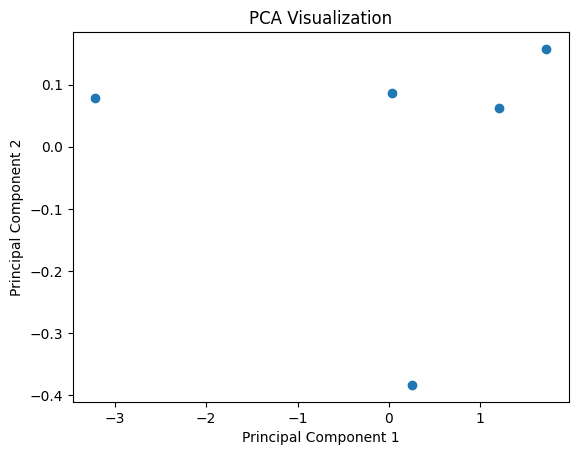

In [22]:
import matplotlib.pyplot as plt

plt.scatter(pca_df['PC1'], pca_df['PC2'])
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization")
plt.show()

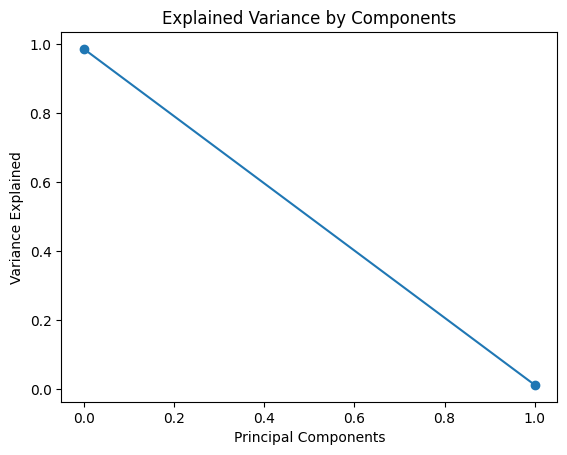

In [23]:
plt.plot(pca.explained_variance_ratio_, marker='o')
plt.xlabel("Principal Components")
plt.ylabel("Variance Explained")
plt.title("Explained Variance by Components")
plt.show()

In [24]:
for n in range(1, 4):
    pca_temp = PCA(n_components=n)
    temp_data = pca_temp.fit_transform(scaled_data)
    print(f"\nComponents: {n}")
    print("Explained Variance:", pca_temp.explained_variance_ratio_)


Components: 1
Explained Variance: [0.98691014]

Components: 2
Explained Variance: [0.98691014 0.01264106]

Components: 3
Explained Variance: [9.86910136e-01 1.26410599e-02 4.48804420e-04]


In [25]:
print("Original Shape:", df.shape)
print("After PCA Shape:", pca_data.shape)

Original Shape: (5, 3)
After PCA Shape: (5, 2)


In [26]:
# Step 1: Mean centering
mean = np.mean(scaled_data, axis=0)
centered_data = scaled_data - mean

# Step 2: Covariance matrix
cov_matrix = np.cov(centered_data, rowvar=False)

# Step 3: Eigen decomposition
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# Step 4: Sort eigenvalues
sorted_index = np.argsort(eigenvalues)[::-1]
sorted_eigenvectors = eigenvectors[:, sorted_index]

# Step 5: Select top components
n_components = 2
eigenvector_subset = sorted_eigenvectors[:, 0:n_components]

# Step 6: Transform data
pca_scratch = np.dot(centered_data, eigenvector_subset)

print(pca_scratch[:5])

[[-1.20779231  0.06176763]
 [-0.02789743  0.08619997]
 [-0.25372528 -0.38389934]
 [-1.72212816  0.15771271]
 [ 3.21154318  0.07821902]]


In [27]:
print("Original Shape:", df.shape)
print("After PCA Shape:", pca_data.shape)

Original Shape: (5, 3)
After PCA Shape: (5, 2)


In [28]:
for n in range(1, 4):
    pca_temp = PCA(n_components=n)
    temp_data = pca_temp.fit_transform(scaled_data)
    print(f"Components: {n}")
    print(pca_temp.explained_variance_ratio_)

Components: 1
[0.98691014]
Components: 2
[0.98691014 0.01264106]
Components: 3
[9.86910136e-01 1.26410599e-02 4.48804420e-04]
